In [ ]:
import numpy as np
from pathlib import Path
import pandas as pd
import akshare as ak
import matplotlib.pyplot as plt
import sys

project_root = project_root = Path(__file__).resolve().parent.parent
src_path = project_root / "src"
sys.path.append(str(src_path))
from metrics import calc_stock_metrics, print_metrics, plot_metrics
from get_single_stock import get_single_stock


东方财富+新浪财经双接口获取股票日线信息

In [ ]:
def to_sina_symbol(symbol: str) -> str:
    """
    将 6 位 A 股代码转换为新浪格式。
    000001 -> sz000001
    600519 -> sh600519
    """
    symbol = str(symbol).zfill(6)

    if symbol.startswith(("6", "5", "9")):
        return "sh" + symbol
    else:
        return "sz" + symbol


def get_a_stock_daily(
    symbol: str,
    start_date: str = "20210101",
    end_date: str | None = None,
    adjust: str = "qfq",
) -> pd.DataFrame:
    """
    获取 A 股日线数据。
    优先使用东方财富 stock_zh_a_hist；
    如果失败，自动切换到新浪 stock_zh_a_daily。
    """
    symbol = str(symbol).zfill(6)

    if end_date is None:
        end_date = pd.Timestamp.today().strftime("%Y%m%d")

    try:
        print(f"尝试使用东方财富接口获取 {symbol}...")

        df = ak.stock_zh_a_hist(
            symbol=symbol,
            period="daily",
            start_date=start_date,
            end_date=end_date,
            adjust=adjust,
            timeout=15,
        )

        if df.empty:
            raise ValueError("东方财富接口返回空数据")

        print(f"东方财富接口成功：{symbol}")
        return df

    except Exception as e:
        print(f"东方财富接口失败：{symbol}")
        print(type(e).__name__, e)
        print(f"尝试切换到新浪接口获取 {symbol}...")

        sina_symbol = to_sina_symbol(symbol)

        df = ak.stock_zh_a_daily(
            symbol=sina_symbol,
            start_date=start_date,
            end_date=end_date,
            adjust=adjust,
        )

        if df.empty:
            raise ValueError(f"新浪接口也返回空数据：{symbol}")

        # 新浪接口没有股票代码列，补一列
        df["symbol"] = symbol

        print(f"新浪接口成功：{symbol}")
        return df

RAW_DIR = project_root / "data" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

symbol = "000001"

df = get_a_stock_daily(
    symbol=symbol,
    start_date="20210101",
    adjust="qfq",
)

print(df.head())
print(df.tail())
print(df.columns)
print(df.info())

output_path = RAW_DIR / f"{symbol}_qfq_daily.csv"
df.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"数据已保存到: {output_path}")

尝试使用东方财富接口获取 000001...
东方财富接口失败：000001
ConnectionError ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
尝试切换到新浪接口获取 000001...
新浪接口成功：000001
         date   open   high    low  close       volume        amount  \
0  2021-01-04  15.26  15.26  14.74  14.86  155421643.0  2.891682e+09   
1  2021-01-05  14.70  14.77  14.22  14.52  182135210.0  3.284607e+09   
2  2021-01-06  14.45  15.63  14.38  15.63  193494512.0  3.648522e+09   
3  2021-01-07  15.60  15.97  15.37  15.90  158418530.0  3.111275e+09   
4  2021-01-08  15.90  16.06  15.43  15.86  119547322.0  2.348316e+09   

   outstanding_share  turnover  symbol  
0       1.940575e+10  0.008009  000001  
1       1.940575e+10  0.009386  000001  
2       1.940575e+10  0.009971  000001  
3       1.940575e+10  0.008163  000001  
4       1.940575e+10  0.006160  000001  
            date   open   high    low  close       volume        amount  \
1318  2026-06-16  11.05  11.12  10.91  10.94   94270804.0  1.0

数据清洗代码，更改日期格式以及按照日期升序排列

In [2]:
# 复制一份，避免直接修改原始 df
data = df.copy()

# 1. 日期转换
data["date"] = pd.to_datetime(data["date"])

# 2. 按日期升序排列
data = data.sort_values("date").reset_index(drop=True)

# 3. 检查缺失值
print("缺失值检查：")
print(data.isna().sum())

# 4. 检查重复日期
print("\n重复日期数量：")
print(data["date"].duplicated().sum())

# 5. 查看数据时间范围
print("\n数据时间范围：")
print(data["date"].min())
print(data["date"].max())

# 6. 查看清洗后的数据类型
print("\n清洗后的数据结构：")
print(data.info())

# 7. 查看前后几行
print("\n前 5 行：")
print(data.head())

print("\n后 5 行：")
print(data.tail())

缺失值检查：
date                 0
open                 0
high                 0
low                  0
close                0
volume               0
amount               0
outstanding_share    0
turnover             0
symbol               0
dtype: int64

重复日期数量：
0

数据时间范围：
2021-01-04 00:00:00
2026-06-23 00:00:00

清洗后的数据结构：
<class 'pandas.DataFrame'>
RangeIndex: 1323 entries, 0 to 1322
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype        
---  ------             --------------  -----        
 0   date               1323 non-null   datetime64[s]
 1   open               1323 non-null   float64      
 2   high               1323 non-null   float64      
 3   low                1323 non-null   float64      
 4   close              1323 non-null   float64      
 5   volume             1323 non-null   float64      
 6   amount             1323 non-null   float64      
 7   outstanding_share  1323 non-null   float64      
 8   turnover           1323 non-null   flo

计算收益率

In [5]:
# pct_change表示计算与前一个数据相比的百分变化率
data["daily_return"] = data["close"].pct_change()
data["daily_return"] = data["daily_return"].fillna(0)
# cumprod表示累乘
data["net_value"] = (1 + data["daily_return"]).cumprod()

print(data[["date", "close", "daily_return", "net_value"]].head(10))
print(data[["date", "close", "daily_return", "net_value"]].tail(10))

        date  close  daily_return  net_value
0 2021-01-04  14.86      0.000000   1.000000
1 2021-01-05  14.52     -0.022880   0.977120
2 2021-01-06  15.63      0.076446   1.051817
3 2021-01-07  15.90      0.017274   1.069987
4 2021-01-08  15.86     -0.002516   1.067295
5 2021-01-11  16.29      0.027112   1.096231
6 2021-01-12  16.78      0.030080   1.129206
7 2021-01-13  16.54     -0.014303   1.113055
8 2021-01-14  16.12     -0.025393   1.084791
9 2021-01-15  16.78      0.040943   1.129206
           date  close  daily_return  net_value
1313 2026-06-09  10.78      0.009363   0.725437
1314 2026-06-10  10.96      0.016698   0.737550
1315 2026-06-11  10.94     -0.001825   0.736205
1316 2026-06-12  11.24      0.027422   0.756393
1317 2026-06-15  11.06     -0.016014   0.744280
1318 2026-06-16  10.94     -0.010850   0.736205
1319 2026-06-17  10.78     -0.014625   0.725437
1320 2026-06-18  10.52     -0.024119   0.707941
1321 2026-06-22  10.65      0.012357   0.716689
1322 2026-06-23  10.71   

计算累积收益、年化收益<br>
年化波动率 = 日收益率标准差 × √252<br>
回撤表示从历史最高点到当日跌了多少<br>
夏普比率表示单位风险对应的收益。简化版本，假设无风险收益率为 0，夏普比率 = 年化收益 / 年化波动率

In [10]:
print(f"股票代码: {data['symbol'].iloc[0]}")
print(f"开始日期: {data['date'].min().date()}")
print(f"结束日期: {data['date'].max().date()}")
print(f"交易日数量: {len(data)}")

cumulative_return = data["net_value"].iloc[-1] - 1
print(f"累计收益：{cumulative_return:.2%}")

trading_days = 252
n_days = len(data)
annual_return = (1 + cumulative_return) ** (trading_days / n_days) - 1
print(f"年化收益: {annual_return:.2%}")

annual_volatility = data["daily_return"].std() * np.sqrt(252)
print(f"年化波动率: {annual_volatility:.2%}")

data["rolling_max"] = data["net_value"].cummax()
data["drawdown"] = data["net_value"] / data["rolling_max"] - 1
max_drawdown = data["drawdown"].min()
print(f"最大回撤: {max_drawdown:.2%}")

sharpe_ratio = annual_return / annual_volatility
print(f"夏普比率: {sharpe_ratio:.2f}")

股票代码: 000001
开始日期: 2021-01-04
结束日期: 2026-06-23
交易日数量: 1323
累计收益：-27.93%
年化收益: -6.05%
年化波动率: 27.68%
最大回撤: -62.31%
夏普比率: -0.22


寻找最大回撤区间

In [11]:
# 找到最大回撤最低点
max_drawdown_end_idx = data["drawdown"].idxmin()
max_drawdown_end_date = data.loc[max_drawdown_end_idx, "date"]
max_drawdown_end_value = data.loc[max_drawdown_end_idx, "net_value"]

# 在最大回撤最低点之前，找到历史最高点
max_drawdown_start_idx = data.loc[:max_drawdown_end_idx, "net_value"].idxmax()
max_drawdown_start_date = data.loc[max_drawdown_start_idx, "date"]
max_drawdown_start_value = data.loc[max_drawdown_start_idx, "net_value"]

print(f"最大回撤开始日期: {max_drawdown_start_date.date()}")
print(f"最大回撤结束日期: {max_drawdown_end_date.date()}")
print(f"回撤前最高净值: {max_drawdown_start_value:.4f}")
print(f"回撤最低净值: {max_drawdown_end_value:.4f}")
print(f"最大回撤幅度: {max_drawdown:.2%}")

最大回撤开始日期: 2021-05-26
最大回撤结束日期: 2023-12-20
回撤前最高净值: 1.3553
回撤最低净值: 0.5108
最大回撤幅度: -62.31%


绘图：净值曲线与回撤曲线

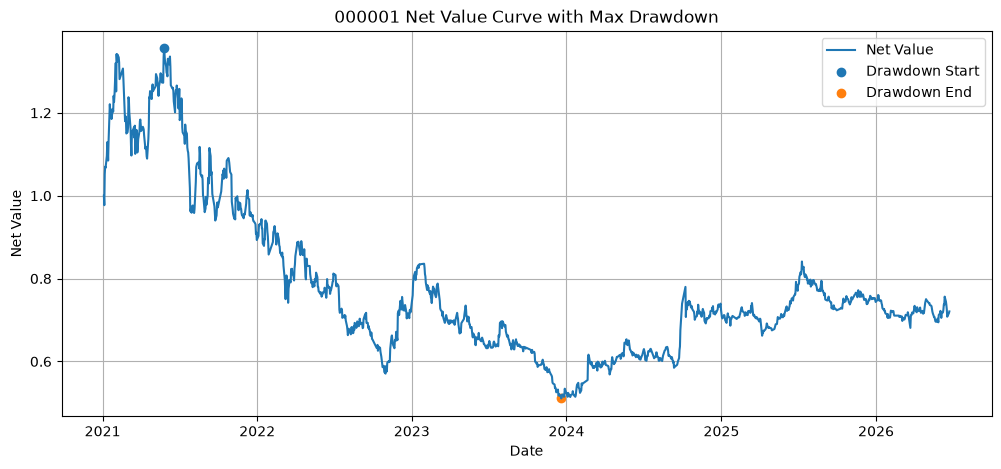

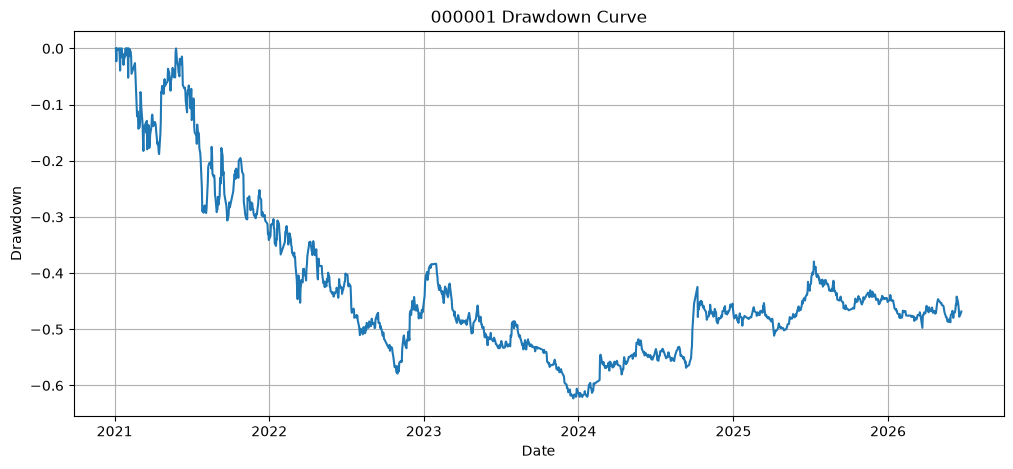

In [16]:
# 画净值曲线
plt.figure(figsize=(12, 5))
plt.plot(data["date"], data["net_value"], label="Net Value")
# 标记最大回撤起点
plt.scatter(max_drawdown_start_date, max_drawdown_start_value, label="Drawdown Start")
# 标记最大回撤终点
plt.scatter(max_drawdown_end_date, max_drawdown_end_value, label="Drawdown End")

plt.title("000001 Net Value Curve with Max Drawdown")
plt.xlabel("Date")
plt.ylabel("Net Value")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(12, 5))
plt.plot(data["date"], data["drawdown"])
plt.title("000001 Drawdown Curve")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.show()